In [1]:
import nicegalaxy
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, KDTree, ConvexHull
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict
from numba import njit
import heapq
import sys, time
import h5py
from scipy.spatial import ConvexHull, HalfspaceIntersection
from scipy.optimize import linprog

In [2]:
galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[30])

In [1]:
structured = nicegalaxy.structured_column(galaxy.gas["Coordinates"], galaxy.gas["Density"], 310)

NameError: name 'nicegalaxy' is not defined

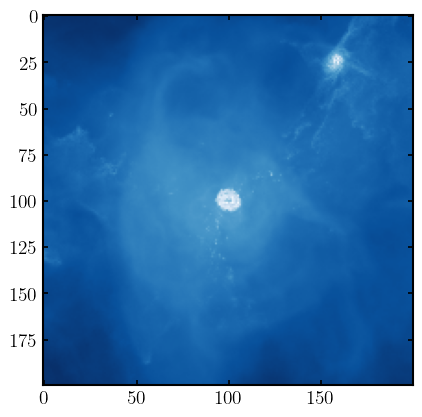

In [4]:
fig, ax = plt.subplots()
ax.imshow(np.log10(structured), cmap="Blues_r")
fig.show()

In [3]:
vor = Voronoi(galaxy.gas["Coordinates"])

neighbors = defaultdict(set)
for p1, p2 in vor.ridge_points:
    neighbors[p1].add(p2)
    neighbors[p2].add(p1)

In [18]:
import numpy as np
from scipy.spatial import Voronoi, KDTree, ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_voronoi_3d(ax, vor, grid=100, draw=None):
    rng = np.random.default_rng(11)

    xlim = (vor.points[:, 0].min(), vor.points[:, 0].max())
    ylim = (vor.points[:, 1].min(), vor.points[:, 1].max())
    zlim = (vor.points[:, 2].min(), vor.points[:, 2].max())

    x = np.linspace(xlim[0], xlim[1], grid)
    y = np.linspace(ylim[0], ylim[1], grid)
    z = np.linspace(zlim[0], zlim[1], grid)
    X,Y,Z = np.meshgrid(x,y,z)
    gridpoints = np.column_stack((X.flatten(),Y.flatten(),Z.flatten()))
    tree = KDTree(vor.points)

    _, idx = tree.query(gridpoints)

    for voronoi_idx in np.unique(idx):
        region_index = vor.point_region[voronoi_idx]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue

        if draw is not None:
            if not np.any(np.all(vor.points[voronoi_idx] == draw, axis=1)):
                continue

        idx_polygon = idx==voronoi_idx
        # create a convex hull around the point cloud
        hull = ConvexHull(gridpoints[idx_polygon])    
        polygon = Poly3DCollection(hull.points[hull.simplices], alpha=0.3, 
                                facecolors=rng.uniform(0,1,3),
                                linewidths=0,edgecolors='gray')
        ax.add_collection3d(polygon)


    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim)


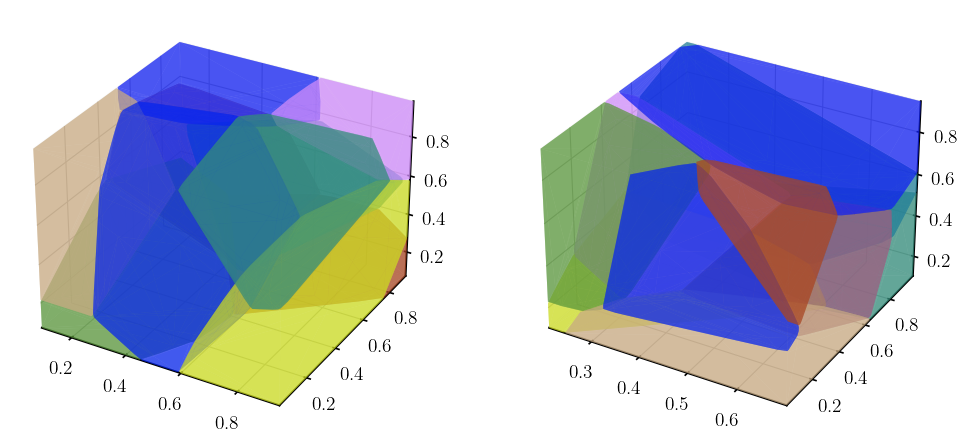

In [42]:
np.random.seed(0)
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')


points = np.random.rand(10, 3)

vor = Voronoi(points)
plot_voronoi_3d(ax1, vor)
points = np.random.rand(10, 3)

vor = Voronoi(points)
plot_voronoi_3d(ax2, vor)

In [ ]:
def get_cell_volumes_hull(vor, grid=50):
    xlim = (vor.points[:, 0].min(), vor.points[:, 0].max())
    ylim = (vor.points[:, 1].min(), vor.points[:, 1].max())
    zlim = (vor.points[:, 2].min(), vor.points[:, 2].max())

    x = np.linspace(xlim[0], xlim[1], grid)
    y = np.linspace(ylim[0], ylim[1], grid)
    z = np.linspace(zlim[0], zlim[1], grid)
    X,Y,Z = np.meshgrid(x,y,z)
    gridpoints = np.column_stack((X.flatten(),Y.flatten(),Z.flatten()))
    tree = KDTree(vor.points)

    _, idx = tree.query(gridpoints)

    volumes = dict()
    for voronoi_idx in np.unique(idx):
            idx_polygon = idx==voronoi_idx
            hull = ConvexHull(gridpoints[idx_polygon])    
            volumes[voronoi_idx] = hull.volume
    return volumes


def mirrored_points(points):
    lims = [
        (points[:, 0].min(), points[:, 0].max()),
        (points[:, 1].min(), points[:, 1].max()),
        (points[:, 2].min(), points[:, 2].max())
    ]
    mirr = list()
    for i in range(3):
        for point in points:
            pad_point_left = point.copy()
            pad_point_right = point.copy()
            pad_point_left[i] = 2*lims[i][0] - point[i]
            pad_point_right[i] = 2*lims[i][1] - point[i]
            mirr.append(pad_point_left)
            mirr.append(pad_point_right)
    return mirr


def mirrored_points_faster(points):
    lims = np.array([
        [points[:, 0].min(), points[:, 0].max()],
        [points[:, 1].min(), points[:, 1].max()],
        [points[:, 2].min(), points[:, 2].max()]
    ])

    mirr = np.zeros((6*len(points), 3))
    for i in range(3):
        mirr[i*len(points):(i+1)*len(points)] = points
        mirr[(i + 1)*len(points):(i+2)*len(points)] = points
        mirr[i*len(points):(i+1)*len(points), i] = 2*lims[i, 0] - points[:, i]
        mirr[(i + 1)*len(points):(i+2)*len(points), i] = 2*lims[i, 1] - points[:, i]
    return mirr


        # this works but is 10x slower and a little worse
        # vor_with = Voronoi([positions[idx] for idx in neigh] + [positions[smallest]])
        # vor_without = Voronoi([positions[idx] for idx in neigh])
        # vols_with_hull = get_cell_volumes_hull(vor_with, grid=grid)
        # vols_without_hull = get_cell_volumes_hull(vor_without, grid=grid)
        # for idx in vols_without_hull:
        #     delta_v += vols_without_hull[idx] - vols_with_hull[idx]

In [ ]:
def get_cell_volumes(vor, start, n):
    volumes = []
    for i in range(start, n):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        try:
            verts = np.array([vor.vertices[j] for j in region])
            # if len(verts) < 4:
            #     continue
            hull = ConvexHull(verts)
            volumes.append(hull.volume)
        except:
            volumes.append(0)
    return volumes


# @njit
def mirrored_points_stable(points):
    lims = np.array([
        [points[:, 0].min(), points[:, 0].max()],
        [points[:, 1].min(), points[:, 1].max()],
        [points[:, 2].min(), points[:, 2].max()]
    ])
    N = len(points)
    mirr = np.zeros((6 * N, 3), dtype=points.dtype)
    for i in range(3):
        start = 2 * i * N
        mirr[start:start+N] = points
        mirr[start+N:start+2*N] = points
        mirr[start:start+N, i] = 2 * lims[i, 0] - points[:, i]
        mirr[start+N:start+2*N, i] = 2 * lims[i, 1] - points[:, i]
    return mirr 


def update_progress(fraction_done, bar_length=40):
    percent = int(fraction_done * 100)
    filled_len = int(bar_length * fraction_done)
    bar = '=' * filled_len + '-' * (bar_length - filled_len)
    sys.stdout.write(f'\r[{bar}] {percent:3d}%')
    sys.stdout.flush()
    

def derefine(neighbors, positions, values, vols, maxres=-1):  
    if maxres < 0:
        maxres = np.max(vols)
    active = np.ones(len(positions), dtype=np.bool)

    mirror_time = 0
    voronoi_time = 0
    volume_time = 0


    count = 0
    error = 0
    while np.min(vols[active]) < maxres:
        subset_indices = np.where(active)[0]
        smallest_active = np.argmin(vols[active])
        smallest = subset_indices[smallest_active]
        active[smallest] = 0
        # redistribute vols and value across neighboring points
        neigh = neighbors[smallest]
        delta_v = 0
        
        points_with_mirr = np.zeros((7*len(neigh) + 1, 3))
        points_with_mirr[1:(len(neigh) + 1)] = positions[list(neigh)]
        points_with_mirr[0] = positions[smallest]
        points_with_mirr[(len(neigh) + 1):] = mirrored_points_stable(points_with_mirr[1:(len(neigh) + 1)])

        vor_with = Voronoi(points_with_mirr)
        vor_without = Voronoi(points_with_mirr[1:])

        before = time.time()
        vols_with = get_cell_volumes(vor_with, 0, len(neigh) + 1)
        vols_without = get_cell_volumes(vor_without, 0, len(neigh))
        after = time.time()
        volume_time += after - before

        for i in range(len(vols_without)):
            delta_v += vols_without[i] - vols_with[i + 1]

        error += np.abs(delta_v - vols[smallest])
        count += 1
        if count > 1000:
            break
    return error, mirror_time, voronoi_time, volume_time


refined_quantities = ["Masses", "InternalEnergy", "Density", "Velocities", "ElectronAbundance", "Machnumber", "MagneticField"]


def save_refined(gas, new_gas, active, level, res):
    refined_gas = dict()
    refined_gas["ParticleIDs"] = gas["ParticleIDs"][active]
    for key in new_gas:
        refined_gas[key] = new_gas[key][active]
        refined_gas[f"{key}_old"] = gas[key][active]
    with h5py.File(f"data/refined/{nicegalaxy.galaxies[30]}_{level:3d}") as f:
        f.create_dataset("DerefinementLevel", data=level)
        f.create_dataset("DerefinementRes", data=res)
        f.create_dataset("ParticlesIDs", data=gas["ParticleIDs"][active])
        for key, array in new_gas.items():
            f.create_dataset(key, data=array[active])
            f.create_dataset(f"{key}_old", data=gas[active])


def derefine_queue(neighbors, vor, positions, vols, gas, maxres=-1):  
    new_gas = dict()
    for key in refined_quantities:
        new_gas[key] = gas[key].copy()

    # new_gas["InternalEnergy"] = new_gas["InternalEnergy"] * new_gas["Masses"]
    refinement_stages = np.linspace(vols.min(), vols.max(), 100)
    current_stage_level = 0
    
    if maxres < 0:
        maxres = np.max(vols)

    mask2 = vols < maxres
    active = np.ones(len(positions), dtype=np.bool)
    active[~mask2] = 0
    subset_indices = np.where(active)[0]
    queue = sorted(subset_indices, key=lambda x: vols[x])

    count = 0
    error = 0
    set_time = np.zeros(1000)
    vor_time = np.zeros(1000)
    vol_time = np.zeros(1000)
    for k, idx in enumerate(queue):
        # update_progress(i/len(queue))
        if vols[idx] >= maxres:
            continue
        region = vor.regions[vor.point_region[idx]]
        if (-1 in region) or len(region) == 0:
            continue
        active[idx] = 0

        # if vols[idx] > refinement_stages[current_stage_level]:
        #     print(f"Saving derefinement level {current_stage_level}. Cells are bigger than {refinement_stages[current_stage_level]}")
        #     save_refined(gas, new_gas, active, current_stage_level, refinement_stages[current_stage_level])
        #     current_stage_level += 1

        # redistribute vols and value across neighboring points
        neigh = neighbors[idx]
        delta_v = 0
        
        neigh_list = list(neigh)
        points_with_mirr = np.zeros((7*len(neigh) + 1, 3))
        points_with_mirr[1:(len(neigh) + 1)] = positions[neigh_list]
        points_with_mirr[0] = positions[idx]
        points_with_mirr[(len(neigh) + 1):] = mirrored_points_stable(points_with_mirr[1:(len(neigh) + 1)])

        before = time.time()
        vor_with = Voronoi(points_with_mirr)
        vor_without = Voronoi(points_with_mirr[1:])
        after = time.time()
        vor_time[k] = after - before

        before = time.time()
        vols_with = get_cell_volumes(vor_with, 0, len(neigh) + 1)
        vols_without = get_cell_volumes(vor_without, 0, len(neigh))
        after = time.time()
        vol_time[k] = after - before


        for i in range(len(vols_without)):
            dv = vols_without[i] - vols_with[i + 1]
            frac = (vols_without[i] - vols_with[i + 1])/vols_with[0]
            new_mass = new_gas["Masses"][neigh_list[i]] + frac*gas["Masses"][idx]
            new_gas["InternalEnergy"][neigh_list[i]] = (frac*gas["Masses"][idx]*gas["InternalEnergy"][idx] + gas["InternalEnergy"][neigh_list[i]]*gas["Masses"][neigh_list[i]])/new_mass
            new_gas["Velocities"][neigh_list[i]] = (frac*gas["Masses"][idx]*gas["Velocities"][idx] + gas["Velocities"][neigh_list[i]]*gas["Masses"][neigh_list[i]])/new_mass
            new_gas["Density"][neigh_list[i]] = new_mass/(vols[neigh_list[i]] + dv)
            new_gas["ElectronAbundance"][neigh_list[i]] = (frac*gas["Masses"][idx] * gas["ElectronAbundance"][idx] + gas["Masses"][neigh_list[i]] * gas["ElectronAbundance"][neigh_list[i]])/new_mass
            new_gas["Machnumber"][neigh_list[i]] = (dv * gas["Machnumber"][idx] + vols[neigh_list[i]] * gas["Machnumber"][neigh_list[i]])/(vols[neigh_list[i]] + dv)
            new_gas["MagneticField"][neigh_list[i]] = (dv * gas["MagneticField"][idx] + vols[neigh_list[i]] * gas["MagneticField"][neigh_list[i]])/(vols[neigh_list[i]] + dv)
            new_gas["Masses"][neigh_list[i]] = new_mass
            vols[neigh_list[i]] += dv
            delta_v += dv

        error += np.abs(delta_v - vols[idx])
        count += 1
        if count > 999:
            break
        before = time.time()
        # for neigh_idx in neigh_list:
        #     neighbors[neigh_idx].update(neighbors[idx])
        #     neighbors[neigh_idx].remove(neigh_idx)
        #     neighbors[neigh_idx].remove(idx)
        # for neigh_idx in neigh_list:
        #     neighbors[neigh_idx] = neighbors[neigh_idx].union(neighbors[idx] - {neigh_idx})
        #     neighbors[neigh_idx].remove(idx)
        after = time.time()
        set_time[k] = after - before
    
    refined_gas = dict()
    refined_gas["ParticleIDs"] = gas["ParticleIDs"][active]
    for key in new_gas:
        refined_gas[key] = new_gas[key][active]
        refined_gas[f"{key}_old"] = gas[key][active]
    return refined_gas, error, set_time, vor_time, vol_time

In [3]:
neighbors = defaultdict(set)
for p1, p2 in vor.ridge_points:
    neighbors[p1].add(p2)
    neighbors[p2].add(p1)

result = derefine_queue(neighbors, vor, galaxy.gas["Coordinates"], galaxy.gas["Masses"]/galaxy.gas["Density"], galaxy.gas)
print(result[1])

NameError: name 'vor' is not defined

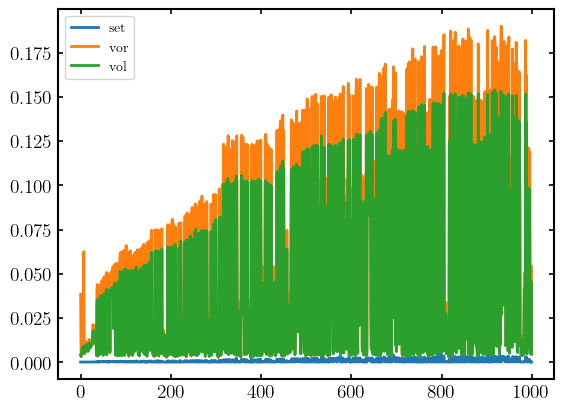

In [68]:
plt.plot(result[2], label="set")
plt.plot(result[3], label="vor")
plt.plot(result[4], label="vol")
plt.legend()

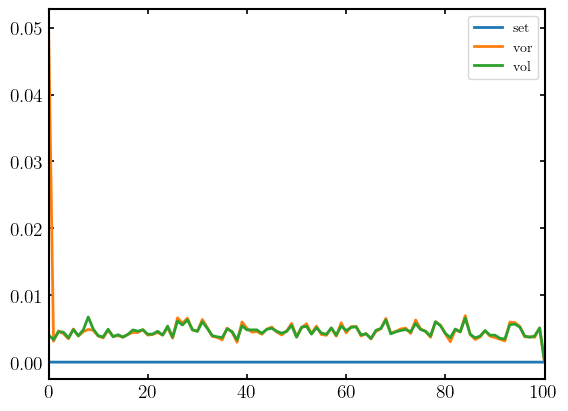

In [58]:
plt.plot(result[2], label="set")
plt.plot(result[3], label="vor")
plt.plot(result[4], label="vol")
plt.xlim((0, 100))
plt.legend()

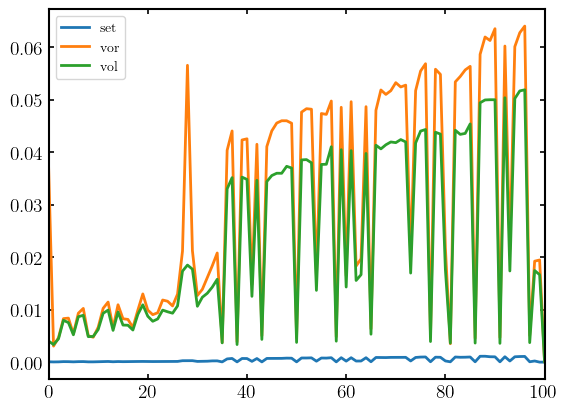

In [ ]:
plt.plot(result[2], label="set")
plt.plot(result[3], label="vor")
plt.plot(result[4], label="vol")
plt.xlim((0, 100))
plt.legend()

In [47]:
result[0]["ParticleIDs"].shape, galaxy.gas["ParticleIDs"].shape

((1735919,), (1736021,))

In [ ]:

Slicing: 100%|██████████| 200/200 [00:05<00:00, 33.98it/s]

16.16841959953308
(np.float32(0.008431328), 0.0868062973022461, 5.085726737976074, 4.718235969543457) 9.890769004821777

np.float32(1930.597)

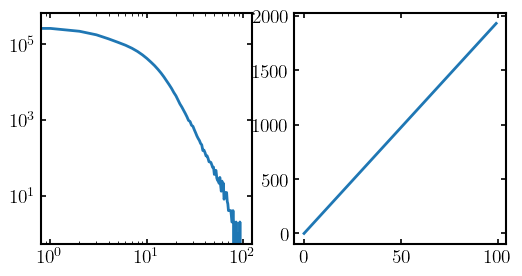

In [61]:
vols = galaxy.gas["Masses"]/galaxy.gas["Density"]
levels = np.linspace(vols.min(), vols.max(), 100)
numbers = np.array([np.sum(vols < level) for level in levels])
numbers[1:] -= numbers[:-1]
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].plot(numbers[1:])
axs[0].set_yscale("log")
axs[0].set_xscale("log")

axs[1].plot(levels)
levels[-1]

[]


0
1
2
3
[0.6670971579218109, 2.1668958333333346, 2.586177476280293, 2.5861774762802927]


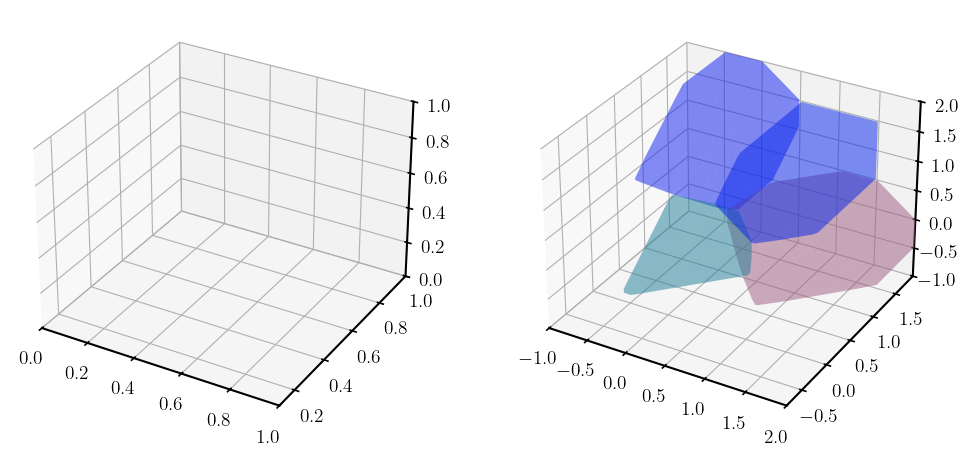

In [8]:
np.random.seed(0)
points = np.array([[0.1, 0.1, 0.1], [1, 1, 1], [0, 1, 1], [1, 1, 0]])
mirr = mirrored_points(points)

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

vor = Voronoi(points)
print(get_cell_volumes(vor))
plot_voronoi_3d(ax1, vor)

vor = Voronoi([point for point in points] + mirr)
plot_voronoi_3d(ax2, vor)

print(get_cell_volumes(vor))

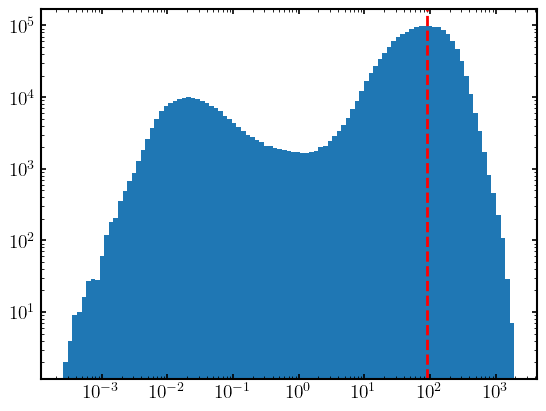

91.31547 4.5031333


In [67]:
vols = galaxy.gas["Masses"]/galaxy.gas["Density"]

bins = np.logspace(np.log10(vols.min()), np.log10(vols.max()), 100)
plt.hist(vols, bins=bins)
plt.axvline(np.mean(vols), linestyle="--", color="red")
plt.xscale("log")
plt.yscale("log")
plt.show()
print(np.mean(vols), np.pow(np.mean(vols), 1/3))

In [68]:
grid_size = int((galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min())/4.5)
print(grid_size)

binsx = np.linspace(galaxy.gas["Coordinates"][:, 0].min(), galaxy.gas["Coordinates"][:, 0].max(), grid_size + 1)
binsx[0] -= 1
binsy = np.linspace(galaxy.gas["Coordinates"][:, 1].min(), galaxy.gas["Coordinates"][:, 1].max(), grid_size + 1)
binsy[0] -= 1
binsz = np.linspace(galaxy.gas["Coordinates"][:, 2].min(), galaxy.gas["Coordinates"][:, 2].max(), grid_size + 1)
binsz[0] -= 1

idxx = np.digitize(galaxy.gas["Coordinates"][:, 0], binsx, right=True)
idxy = np.digitize(galaxy.gas["Coordinates"][:, 1], binsy, right=True)
idxz = np.digitize(galaxy.gas["Coordinates"][:, 2], binsz, right=True)

120


In [4]:
vor = Voronoi(galaxy.gas["Coordinates"])

In [5]:
def mirrored_points_frame(points, center, frac=0.1):
    lims = np.array([
        [points[:, 0].min(), points[:, 0].max()],
        [points[:, 1].min(), points[:, 1].max()],
        [points[:, 2].min(), points[:, 2].max()]
    ])

    inner = (lims[0, 1] - lims[0, 0]) * (1 - frac)/2
    in_middle = np.max(np.abs(points - center), axis=-1) < inner
    frame_points = points[~in_middle]
    # frame_density = density[~in_middle]
    N = len(frame_points)
    mirr = np.zeros((6 * N, 3), dtype=points.dtype)
    # dens = np.zeros((6 * N), dtype=points.dtype)
    for i in range(3):
        start = 2 * i * N
        mirr[start:start+N] = frame_points
        mirr[start+N:start+2*N] = frame_points
        mirr[start:start+N, i] = 2 * lims[i, 0] - frame_points[:, i]
        mirr[start+N:start+2*N, i] = 2 * lims[i, 1] - frame_points[:, i]
        # dens[start:start+N] = frame_density
        # dens[start+N:start+2*N] = frame_density

    cropped = mirr[np.max(np.abs(mirr - center), axis=-1) < (((lims[0, 1] - lims[0, 0]))*(1 + frac)/2)]
    # cropped_dens = dens[np.max(np.abs(mirr - center), axis=-1) < (((lims[0, 1] - lims[0, 0]))*(1 + frac)/2)]
    return np.concatenate((points, cropped))

In [6]:
points_with_mirr = mirrored_points_frame(galaxy.gas["Coordinates"], galaxy.bhs["Coordinates"][0])

In [5]:
structured_gas = nicegalaxy.structured_column(points_with_mirr[2], points_with_mirr[3], grid_size=500)

Slicing: 100%|██████████| 500/500 [00:32<00:00, 15.23it/s]


In [6]:
box_length = points_with_mirr[2][:, 0].max() - points_with_mirr[2][:, 0].min()
min_corner = points_with_mirr[2].min(axis=0)
max_corner = points_with_mirr[2].max(axis=0)

In [7]:
print(box_length)
from mpl_toolkits.axes_grid1 import make_axes_locatable


595.2149967034966


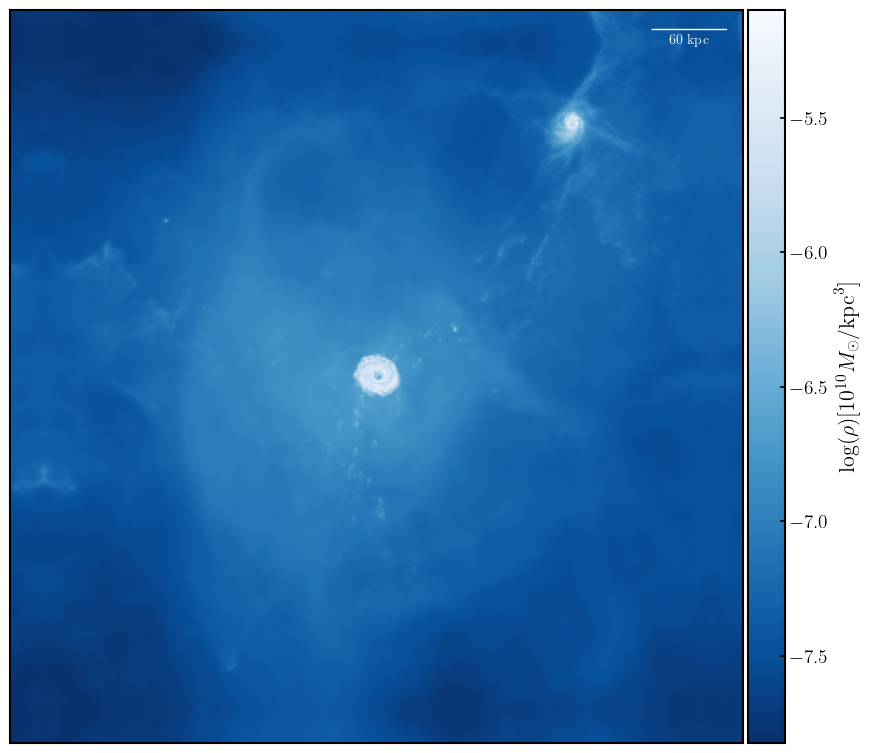

In [16]:
fig, ax = plt.subplots(figsize=(10,10))
scalebar_length = round(box_length/10)
scalebar_pixels = scalebar_length/box_length * structured_gas.shape[0]
center = 0.5 * (max_corner + min_corner)
closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
im = ax.imshow(np.log10(structured_gas), cmap="Blues_r", interpolation=None)
ax.plot([structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels, structured_gas.shape[0]*(1 - 1/40)], [structured_gas.shape[0]/40, structured_gas.shape[0]/40], color='white', linewidth=1)
ax.text(structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels/2, structured_gas.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
# ax.text(structured_gas.shape[0]*1/40, structured_gas.shape[0]*1/40, rf"$d_{{\mathrm{{BH}}}} = {closest_bh_dist:.1f} \mathrm{{kpc}}, d_{{\mathrm{{GC}}}} = {gc_dist:.1f} \mathrm{{kpc}}$", va="top", color="white")
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, label=r"$\log(\rho) [10^{10} M_{\odot}/\mathrm{kpc}^3]$")# label=r"$\mathrm{log}(\rho) $")
fig.savefig("padded_galaxy.png")

In [5]:
len(points_with_mirr)/len(galaxy.gas["Coordinates"])

1.748760527666428

In [ ]:
def mirrored_points_frame(points, center, frac=0.1):
    lims = np.array([
        [points[:, 0].min(), points[:, 0].max()],
        [points[:, 1].min(), points[:, 1].max()],
        [points[:, 2].min(), points[:, 2].max()]
    ])

    inner = (lims[0, 1] - lims[0, 0]) * (1 - frac)/2
    in_middle = np.max(np.abs(points - center), axis=-1) < inner
    frame_points = points[~in_middle]
    # frame_density = density[~in_middle]
    N = len(frame_points)
    mirr = np.zeros((6 * N, 3), dtype=points.dtype)
    # dens = np.zeros((6 * N), dtype=points.dtype)
    for i in range(3):
        start = 2 * i * N
        mirr[start:start+N] = frame_points
        mirr[start+N:start+2*N] = frame_points
        mirr[start:start+N, i] = 2 * lims[i, 0] - frame_points[:, i]
        mirr[start+N:start+2*N, i] = 2 * lims[i, 1] - frame_points[:, i]
        # dens[start:start+N] = frame_density
        # dens[start+N:start+2*N] = frame_density

    cropped = mirr[np.max(np.abs(mirr - center), axis=-1) < (((lims[0, 1] - lims[0, 0]))*(1 + frac)/2)]
    # cropped_dens = dens[np.max(np.abs(mirr - center), axis=-1) < (((lims[0, 1] - lims[0, 0]))*(1 + frac)/2)]
    return np.concatenate((points, cropped))


points_with_mirr = mirrored_points_frame(galaxy.gas["Coordinates"], galaxy.bhs["Coordinates"][0])

In [7]:
vor_with_mirr = Voronoi(points_with_mirr)

In [46]:
from scipy.spatial import QhullError

In [ ]:
def get_cell_volumes(vor, start, n):
    volumes = []
    for i in range(start, n):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        try:
            verts = np.array([vor.vertices[j] for j in region])
            hull = ConvexHull(verts)
            volumes.append(hull.volume)
        except:
            volumes.append(0)
    return volumes


def cube_halfspaces(xmin, xmax, ymin, ymax, zmin, zmax):
    return np.array([
        [-1, 0, 0, xmin],  
        [1, 0, 0, -xmax],  
        [0, -1, 0, ymin], 
        [0, 1, 0, -ymax],  
        [0, 0, -1, zmin],
        [0, 0, 1, -zmax]  
    ])


def derefine(vor, gas, minvol=-1):
    vols = gas["Masses"]/gas["Density"]
    if minvol < 0:
        minvol = np.mean(vols)
    grid_size = int((gas["Coordinates"][:, 0].max() - gas["Coordinates"][:, 0].min())/(minvol**(1/3)))

    binsx = np.linspace(gas["Coordinates"][:, 0].min(), gas["Coordinates"][:, 0].max(), grid_size + 1)
    binsx[0] -= 1
    binsy = np.linspace(gas["Coordinates"][:, 1].min(), gas["Coordinates"][:, 1].max(), grid_size + 1)
    binsy[0] -= 1
    binsz = np.linspace(gas["Coordinates"][:, 2].min(), gas["Coordinates"][:, 2].max(), grid_size + 1)
    binsz[0] -= 1
    # idxx = np.digitize(gas["Coordinates"][:, 0], binsx, right=True)
    # idxy = np.digitize(gas["Coordinates"][:, 1], binsy, right=True)
    # idxz = np.digitize(gas["Coordinates"][:, 2], binsz, right=True)
    binsx[0] += 1
    binsy[0] += 1
    binsz[0] += 1

    derefined_mass = np.zeros((grid_size, grid_size, grid_size))

    error = 0
    qhull_errors = 0

    for gas_i in range(1000): # range(len(gas["Coordinates"])):
        region_index = vor.point_region[gas_i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        verts = np.array([vor.vertices[j] for j in region])

        xlim = (verts[:, 0].min(), verts[:, 0].max())
        ylim = (verts[:, 1].min(), verts[:, 1].max())
        zlim = (verts[:, 2].min(), verts[:, 2].max())
    
        idxxlim = (np.ceil((xlim[0] - binsx[0])/(binsx[-1] - binsx[0]) * grid_size), np.ceil((xlim[1] - binsx[0])/(binsx[-1] - binsx[0]) * grid_size))
        idxylim = (np.ceil((ylim[0] - binsy[0])/(binsy[-1] - binsy[0]) * grid_size), np.ceil((ylim[1] - binsy[0])/(binsy[-1] - binsy[0]) * grid_size))
        idxzlim = (np.ceil((zlim[0] - binsz[0])/(binsz[-1] - binsz[0]) * grid_size), np.ceil((zlim[1] - binsz[0])/(binsz[-1] - binsz[0]) * grid_size))

        vol_tot = 0

        for i in range(max(int(idxxlim[0]), 1), int(idxxlim[1]) + 1):
            for j in range(max(int(idxylim[0]), 1), int(idxylim[1]) + 1):
                for k in range(max(int(idxzlim[0]), 1), int(idxzlim[1]) + 1):
                    # binsx[i - 1], binsx[i]
                    hull = ConvexHull(verts)

                    poly_halfspaces = []
                    for simplex in hull.equations:
                        normal = simplex[:-1]
                        offset = simplex[-1]
                        poly_halfspaces.append(np.append(normal, offset))

                    poly_halfspaces = np.array(poly_halfspaces)
                    hs = np.vstack((cube_halfspaces(binsx[i - 1], binsx[i], binsy[j - 1], binsy[j], binsz[k - 1], binsz[k]), poly_halfspaces))

                    norm_vector = np.reshape(np.linalg.norm(hs[:, :-1], axis=1), (hs.shape[0], 1))
                    c = np.zeros((hs.shape[1],))
                    c[-1] = -1
                    A = np.hstack((hs[:, :-1], norm_vector))
                    b = - hs[:, -1:]
                    res = linprog(c, A_ub=A, b_ub=b, bounds=(None, None))
                    interior_point = res.x[:-1]

                    try:
                        hs_int = HalfspaceIntersection(hs, interior_point)
                    except QhullError:
                        # print("QhullError. Moving on")
                        qhull_errors += 1
                        continue

                    intersection_hull = ConvexHull(hs_int.intersections)
                    volume = intersection_hull.volume
                    vol_tot += volume
                    derefined_mass[i - 1, j - 1, k - 1] += volume*gas["Density"][gas_i]
        error += np.abs(vol_tot - gas["Masses"][gas_i]/gas["Density"][gas_i])
    return derefined_mass, error


In [ ]:
derefined_mass, error = derefine(vor_with_mirr, galaxy.gas)

QhullError. Moving on
QhullError. Moving on
QhullError. Moving on
QhullError. Moving on
8.336967e-05


In [16]:
print(derefined_mass[derefined_mass > 0])

[2.04924902e-07]


In [51]:
len(galaxy.gas["Coordinates"])

1736021

In [ ]:
derefined_mass = np.zeros((grid_size, grid_size, grid_size))
derefined_momentum = np.zeros((grid_size, grid_size, grid_size, 3))


for i in range(len(galaxy.gas["Masses"])):
    derefined_mass[idxx[i] - 1, idxy[i] - 1, idxz[i] - 1] += galaxy.gas["Masses"][i]
    derefined_momentum[idxx[i] - 1, idxy[i] - 1, idxz[i] - 1] += galaxy.gas["Masses"][i]*galaxy.gas["Velocities"][i]
    

derefined_velocities = derefined_momentum/derefined_mass[..., np.newaxis]

/tmp/ipykernel_72837/2767330831.py:9: RuntimeWarning: invalid value encountered in divide
  derefined_velocities = derefined_momentum/derefined_mass[..., np.newaxis]


/tmp/ipykernel_72837/3722841626.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.sum(derefined[:, :, 50:70], axis=-1)), cmap="Blues_r", interpolation=None)


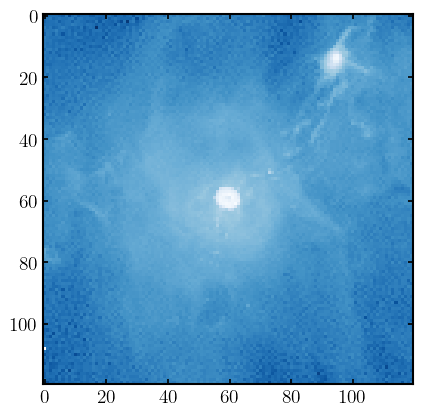

In [ ]:
plt.imshow(np.log10(np.sum(derefined_mass[:, :, 50:70], axis=-1)), cmap="Blues_r", interpolation=None)

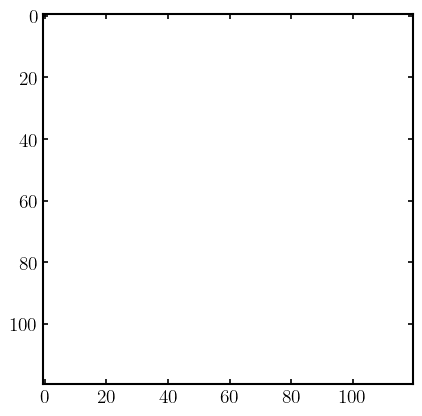

In [75]:
plt.imshow(np.log10(np.sum(np.sqrt(np.sum(derefined_velocities**2, axis=-1)), axis=-1)), cmap="plasma")

In [ ]:
derefined_velocities[np.isnan(derefined_velocities)]

array([[[[          nan,           nan,           nan],
         [          nan,           nan,           nan],
         [ -38.232939  ,   57.02772467,  -34.64024638],
         ...,
         [          nan,           nan,           nan],
         [          nan,           nan,           nan],
         [          nan,           nan,           nan]],

        [[ -40.99608395,   56.43063073,  -38.91603265],
         [          nan,           nan,           nan],
         [          nan,           nan,           nan],
         ...,
         [          nan,           nan,           nan],
         [  -6.71196135,  101.89785083,  -13.40366639],
         [          nan,           nan,           nan]],

        [[          nan,           nan,           nan],
         [          nan,           nan,           nan],
         [          nan,           nan,           nan],
         ...,
         [          nan,           nan,           nan],
         [          nan,           nan,           nan],
  

In [ ]:
import numpy as np
from scipy.spatial import ConvexHull, HalfspaceIntersection
from scipy.optimize import linprog

# Define cube as a list of halfspaces (A x + b <= 0)


# Example convex polyhedron: tetrahedron (4 vertices)
tetra = np.array([
    [0, 0, 0],
    [0.5, 0, 0],
    [0, 0.5, 0],
    [0.5, 0.5, 0],
    [0, 0, 0.5],
    [0.5, 0, 0.5],
    [0, 0.5, 0.5],
    [0.5, 0.5, 0.5]
])
hull = ConvexHull(tetra)

# Convert tetrahedron faces into halfspaces: Ax + b <= 0
# Ax = face normal, b = -dot(normal, vertex)
poly_halfspaces = []
for simplex in hull.equations:
    normal = simplex[:-1]
    offset = simplex[-1]
    poly_halfspaces.append(np.append(normal, offset))

poly_halfspaces = np.array(poly_halfspaces)

# Combine cube and polyhedron halfspaces
hs = np.vstack((cube_halfspaces(0, 1, 0, 1, 0, 1), poly_halfspaces))

# Find an interior point (by linear programming)
c = np.zeros(3)
res = linprog(c, A_ub=hs[:, :3], b_ub=-hs[:, 3])
if not res.success:
    raise RuntimeError("Failed to find an interior point of intersection")

interior_point = res.x
print(interior_point)

# Compute the intersection polyhedron
hs_int = HalfspaceIntersection(hs, np.array([0.25, 0.25, 0.25]))

# Compute volume of the convex intersection
intersection_hull = ConvexHull(hs_int.intersections)
volume = intersection_hull.volume

print("Intersection volume:", volume)


[0. 0. 0.]
Intersection volume: 0.125


In [ ]:
import numpy as np
from scipy.spatial import ConvexHull, HalfspaceIntersection
from scipy.optimize import linprog

# Define cube as a list of halfspaces (A x + b <= 0)
def cube_halfspaces(xmin, xmax, ymin, ymax, zmin, zmax):
    return np.array([
        [-1, 0, 0, xmin],   # x >= xmin → -x + xmin ≤ 0 → +1*x + 0 + 0 + (-xmin) ≤ 0
        [1, 0, 0, -xmax],    # x <= xmax
        [0, -1, 0, ymin],   # y >= ymin
        [0, 1, 0, -ymax],    # y <= ymax
        [0, 0, -1, zmin],   # z >= zmin
        [0, 0, 1, -zmax]     # z <= zmax
    ])

# Example convex polyhedron: tetrahedron (4 vertices)
tetra = np.array([
    [0.5, 0.5, 0.5],
    [1.5, 0.5, 0.5],
    [0.5, 1.5, 0.5],
    [0.5, 0.5, 1.5]
])
hull = ConvexHull(tetra)

# Convert tetrahedron faces into halfspaces: Ax + b <= 0
# Ax = face normal, b = -dot(normal, vertex)
poly_halfspaces = []
for simplex in hull.equations:
    normal = simplex[:-1]
    offset = simplex[-1]
    poly_halfspaces.append(np.append(normal, offset))

poly_halfspaces = np.array(poly_halfspaces)

# Combine cube and polyhedron halfspaces
hs = np.vstack((cube_halfspaces(0, 2, 0, 2, 0, 2), poly_halfspaces))

norm_vector = np.reshape(np.linalg.norm(hs[:, :-1], axis=1), (hs.shape[0], 1))
c = np.zeros((hs.shape[1],))
c[-1] = -1
A = np.hstack((hs[:, :-1], norm_vector))
b = - hs[:, -1:]
res = linprog(c, A_ub=A, b_ub=b, bounds=(None, None))
interior_point = res.x[:-1]

print(interior_point)

# Compute the intersection polyhedron
hs_int = HalfspaceIntersection(hs, interior_point)

# Compute volume of the convex intersection
intersection_hull = ConvexHull(hs_int.intersections)
volume = intersection_hull.volume

print("Intersection volume:", volume)


[0.71132487 0.71132487 0.71132487]
Intersection volume: 0.16666666666666657


In [19]:
norm_vector = np.reshape(np.linalg.norm(halfspaces[:, :-1], axis=1),

    (halfspaces.shape[0], 1))

c = np.zeros((halfspaces.shape[1],))

c[-1] = -1

A = np.hstack((halfspaces[:, :-1], norm_vector))

b = - halfspaces[:, -1:]

res = linprog(c, A_ub=A, b_ub=b, bounds=(None, None))

In [20]:
print(res)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -0.7639320225002103
              x: [ 7.639e-01  7.639e-01  7.639e-01]
            nit: 0
          lower:  residual: [       inf        inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00  0.000e+00  7.639e-01]
                 marginals: [-3.820e-01 -1.910e-01 -1.910e-01 -0.000e+00]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0


In [2]:
from tqdm import tqdm
import concurrent.futures
from scipy.spatial import QhullError
import nicegalaxy
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, KDTree, ConvexHull
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict
from numba import njit
import heapq
import sys, time
import h5py
from scipy.spatial import ConvexHull, HalfspaceIntersection
from scipy.optimize import linprog
from scipy.spatial import QhullError


galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[30])


def mirrored_points_frame(points, center, frac=0.1):
    lims = np.array([
        [points[:, 0].min(), points[:, 0].max()],
        [points[:, 1].min(), points[:, 1].max()],
        [points[:, 2].min(), points[:, 2].max()]
    ])

    inner = (lims[0, 1] - lims[0, 0]) * (1 - frac)/2
    in_middle = np.max(np.abs(points - center), axis=-1) < inner
    frame_points = points[~in_middle]
    # frame_density = density[~in_middle]
    N = len(frame_points)
    mirr = np.zeros((6 * N, 3), dtype=points.dtype)
    # dens = np.zeros((6 * N), dtype=points.dtype)
    for i in range(3):
        start = 2 * i * N
        mirr[start:start+N] = frame_points
        mirr[start+N:start+2*N] = frame_points
        mirr[start:start+N, i] = 2 * lims[i, 0] - frame_points[:, i]
        mirr[start+N:start+2*N, i] = 2 * lims[i, 1] - frame_points[:, i]
        # dens[start:start+N] = frame_density
        # dens[start+N:start+2*N] = frame_density

    cropped = mirr[np.max(np.abs(mirr - center), axis=-1) < (((lims[0, 1] - lims[0, 0]))*(1 + frac)/2)]
    # cropped_dens = dens[np.max(np.abs(mirr - center), axis=-1) < (((lims[0, 1] - lims[0, 0]))*(1 + frac)/2)]
    return np.concatenate((points, cropped))


points_with_mirr = mirrored_points_frame(galaxy.gas["Coordinates"], galaxy.bhs["Coordinates"][0])
vor_with_mirr = Voronoi(points_with_mirr)

In [5]:
len(points_with_mirr)

1967729

In [6]:
from itertools import batched
from functools import partial

In [ ]:
def get_cell_volumes(vor, start, n):
    volumes = []
    for i in range(start, n):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        try:
            verts = np.array([vor.vertices[j] for j in region])
            hull = ConvexHull(verts)
            volumes.append(hull.volume)
        except:
            volumes.append(0)
    return volumes


def cube_halfspaces(xmin, xmax, ymin, ymax, zmin, zmax):
    return np.array([
        [-1, 0, 0, xmin],  
        [1, 0, 0, -xmax],  
        [0, -1, 0, ymin], 
        [0, 1, 0, -ymax],  
        [0, 0, -1, zmin],
        [0, 0, 1, -zmax]  
    ])


def distribute(density, vols, internal_energy, velocities, binsx, binsy, binsz, grid_size, gas_is, vertss): # range(len(gas["Coordinates"])):
        derefined_mass = np.zeros((grid_size, grid_size, grid_size))
        derefined_energy = np.zeros((grid_size, grid_size, grid_size))
        derefined_momentum = np.zeros((grid_size, grid_size, grid_size, 3))
        errors = np.zeros(2)
        for gas_i, verts in zip(gas_is, vertss):
            # region_index = vor.point_region[gas_i]
            # region = vor.regions[region_index]
            # if -1 in region or len(region) == 0:
            #     return
            # verts = np.array([vor.vertices[j] for j in region])

            xlim = (verts[:, 0].min(), verts[:, 0].max())
            ylim = (verts[:, 1].min(), verts[:, 1].max())
            zlim = (verts[:, 2].min(), verts[:, 2].max())
        
            idxxlim = (np.ceil((xlim[0] - binsx[0])/(binsx[-1] - binsx[0]) * grid_size), np.ceil((xlim[1] - binsx[0])/(binsx[-1] - binsx[0]) * grid_size))
            idxylim = (np.ceil((ylim[0] - binsy[0])/(binsy[-1] - binsy[0]) * grid_size), np.ceil((ylim[1] - binsy[0])/(binsy[-1] - binsy[0]) * grid_size))
            idxzlim = (np.ceil((zlim[0] - binsz[0])/(binsz[-1] - binsz[0]) * grid_size), np.ceil((zlim[1] - binsz[0])/(binsz[-1] - binsz[0]) * grid_size))

            vol_tot = 0

            for i in range(max(int(idxxlim[0]), 1), min(int(idxxlim[1]) + 1, len(binsx))):
                for j in range(max(int(idxylim[0]), 1), min(int(idxylim[1]) + 1, len(binsy))):
                    for k in range(max(int(idxzlim[0]), 1), min(int(idxzlim[1]) + 1, len(binsz))):
                        # binsx[i - 1], binsx[i]
                        hull = ConvexHull(verts)

                        poly_halfspaces = []
                        for simplex in hull.equations:
                            normal = simplex[:-1]
                            offset = simplex[-1]
                            poly_halfspaces.append(np.append(normal, offset))

                        poly_halfspaces = np.array(poly_halfspaces)
                        hs = np.vstack((cube_halfspaces(binsx[i - 1], binsx[i], binsy[j - 1], binsy[j], binsz[k - 1], binsz[k]), poly_halfspaces))

                        norm_vector = np.reshape(np.linalg.norm(hs[:, :-1], axis=1), (hs.shape[0], 1))
                        c = np.zeros((hs.shape[1],))
                        c[-1] = -1
                        A = np.hstack((hs[:, :-1], norm_vector))
                        b = - hs[:, -1:]
                        res = linprog(c, A_ub=A, b_ub=b, bounds=(None, None))
                        interior_point = res.x[:-1]

                        try:
                            hs_int = HalfspaceIntersection(hs, interior_point)
                        except QhullError:
                            # print("QhullError. Moving on")
                            errors[1] += 1
                            continue

                        intersection_hull = ConvexHull(hs_int.intersections)
                        volume = intersection_hull.volume
                        vol_tot += volume
                        derefined_mass[i - 1, j - 1, k - 1] += volume*density[gas_i]
                        derefined_energy[i - 1, j - 1, k - 1] += volume*density[gas_i]*internal_energy[gas_i]
                        derefined_momentum[i - 1, j - 1, k - 1] += volume*density[gas_i]*velocities[gas_i]
            errors[0] += np.abs(vol_tot - vols[gas_i])
        return derefined_mass, derefined_energy, derefined_momentum, errors


def derefine(vor, gas, minvol=-1):
    vols = gas["Masses"]/gas["Density"]
    if minvol < 0:
        minvol = np.mean(vols)
    grid_size = int((gas["Coordinates"][:, 0].max() - gas["Coordinates"][:, 0].min())/(minvol**(1/3)))

    binsx = np.linspace(gas["Coordinates"][:, 0].min(), gas["Coordinates"][:, 0].max(), grid_size + 1)
    binsx[0] -= 1
    binsy = np.linspace(gas["Coordinates"][:, 1].min(), gas["Coordinates"][:, 1].max(), grid_size + 1)
    binsy[0] -= 1
    binsz = np.linspace(gas["Coordinates"][:, 2].min(), gas["Coordinates"][:, 2].max(), grid_size + 1)
    binsz[0] -= 1
    # idxx = np.digitize(gas["Coordinates"][:, 0], binsx, right=True)
    # idxy = np.digitize(gas["Coordinates"][:, 1], binsy, right=True)
    # idxz = np.digitize(gas["Coordinates"][:, 2], binsz, right=True)
    binsx[0] += 1
    binsy[0] += 1
    binsz[0] += 1

    tasks = list(range(len(gas["Coordinates"])))
    get_verts = lambda batch: [np.array([vor.vertices[j] for j in region]) for region in [vor.regions[vor.point_region[i]] for i in batch]]
    batched_tasks = [(i_group, get_verts(i_group)) for i_group in batched(tasks, 10000)]

    thread_results = []
    # with concurrent.futures.ThreadPoolExecutor() as executor:
    #     futures = [executor.submit(distribute, i_group) for i_group in batched(tasks, 100)]
    #     for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
    #         thread_results.append(future.result())

    distr = partial(distribute, gas["Density"], gas["Masses"]/gas["Density"], binsx, binsy, binsz, grid_size)
    with concurrent.futures.ProcessPoolExecutor() as executor:
        futures = [executor.submit(distr, i_group, verts) for i_group, verts in batched_tasks]
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            thread_results.append(future.result())

    derefined_mass = np.zeros((grid_size, grid_size, grid_size))
    derefined_energy = np.zeros((grid_size, grid_size, grid_size))
    derefined_momentum = np.zeros((grid_size, grid_size, grid_size, 3))
    errors = np.zeros(2)
    for result in thread_results:
        derefined_mass += result[0]
        derefined_energy += result[1]
        derefined_momentum += result[2]
        errors += result[-1]

    derefined_energy = derefined_energy/derefined_mass
    derefined_momentum = derefined_momentum/derefined_mass[..., np.newaxis]
    derefined_mass = derefined_mass/minvol

    np.save('data/refined_dens.npy', derefined_mass)
    np.save('data/refined_vels.npy', derefined_momentum)
    np.save('data/refined_energy.npy', derefined_energy)

    return derefined_mass, errors

In [4]:
thread_results, grid_size = derefine(vor_with_mirr, galaxy.gas)

100%|██████████| 174/174 [21:32<00:00,  7.43s/it]


In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [7]:
derefined_mass = np.zeros((grid_size, grid_size, grid_size))
errors = np.zeros(2)
for i, result in enumerate(thread_results):
    derefined_mass += result[0]
    fig, ax = plt.subplots(figsize=(8,8))
    box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()
    scalebar_length = round(box_length/10)
    scalebar_pixels = scalebar_length/box_length * derefined_mass.shape[0]
    im = ax.imshow(np.sum(derefined_mass/np.mean(galaxy.gas["Masses"]/galaxy.gas["Density"]), axis=-1)/derefined_mass.shape[0], cmap="Blues_r", interpolation=None, norm="log", vmin=1.5e-8, vmax=2.5e-6)
    ax.plot([derefined_mass.shape[0]*(1 - 1/40) - scalebar_pixels, derefined_mass.shape[0]*(1 - 1/40)], [derefined_mass.shape[0]/40, derefined_mass.shape[0]/40], color='white', linewidth=1)
    ax.text(derefined_mass.shape[0]*(1 - 1/40) - scalebar_pixels/2, derefined_mass.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
    ax.set_xticks([])
    ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax, label=r"$\rho [10^{10} M_{\odot}/\mathrm{kpc}^3]$")# label=r"$\mathrm{log}(\rho) $")
    fig.savefig(f"data/distributing-images/avg/{i:04d}.png", bbox_inches='tight', dpi=300)
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(8,8))
    box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()
    scalebar_length = round(box_length/10)
    scalebar_pixels = scalebar_length/box_length * derefined_mass.shape[0]
    im = ax.imshow(derefined_mass[:, :, int(derefined_mass.shape[0]//2)]/np.mean(galaxy.gas["Masses"]/galaxy.gas["Density"]), cmap="Blues_r", interpolation=None, norm="log", vmin=1.5e-8, vmax=2.5e-6)
    ax.plot([derefined_mass.shape[0]*(1 - 1/40) - scalebar_pixels, derefined_mass.shape[0]*(1 - 1/40)], [derefined_mass.shape[0]/40, derefined_mass.shape[0]/40], color='white', linewidth=1)
    ax.text(derefined_mass.shape[0]*(1 - 1/40) - scalebar_pixels/2, derefined_mass.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
    ax.set_xticks([])
    ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax, label=r"$\rho [10^{10} M_{\odot}/\mathrm{kpc}^3]$")# label=r"$\mathrm{log}(\rho) $")
    fig.savefig(f"data/distributing-images/slice/{i:04d}.png", bbox_inches='tight', dpi=300)
    plt.close(fig)
    errors += result[1]

In [104]:
np.mean(derefined_mass/np.mean(galaxy.gas["Masses"]/galaxy.gas["Density"])), np.sum(galaxy.gas["Masses"])/541**3

(np.float64(6.761134982409251e-08), np.float32(6.73841e-08))

In [100]:
4.5**3

91.125

In [101]:
np.mean(galaxy.gas["Masses"]/galaxy.gas["Density"])

np.float32(91.31547)

In [96]:
bad = np.sum(derefined_mass/np.mean(galaxy.gas["Masses"]/galaxy.gas["Density"]), axis=-1)

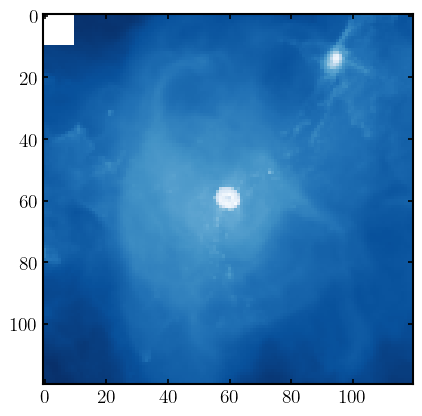

In [84]:
plt.imshow(bad, cmap="Blues_r", norm="log")

In [68]:
error[0], int(error[1])

(np.float64(0.016887062578462064), 35334)

In [69]:
35334/200000

0.17667

In [80]:
thread_results

NameError: name 'thread_results' is not defined

In [87]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

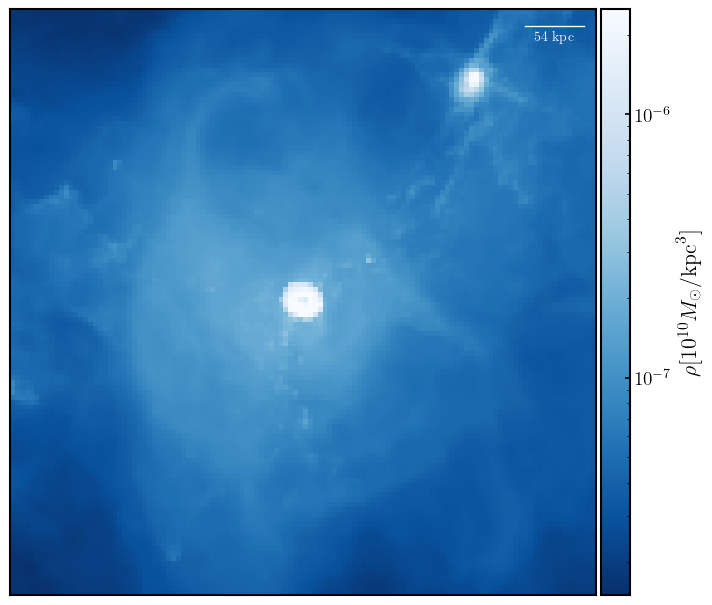

In [113]:
fig, ax = plt.subplots(figsize=(8,8))
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()
min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)
scalebar_length = round(box_length/10)
scalebar_pixels = scalebar_length/box_length * bad.shape[0]
center = 0.5 * (max_corner + min_corner)
closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
im = ax.imshow(np.sum(derefined_mass/np.mean(galaxy.gas["Masses"]/galaxy.gas["Density"]), axis=-1)/derefined_mass.shape[0], cmap="Blues_r", interpolation=None, norm="log", vmin=1.5e-8, vmax=2.5e-6)
ax.plot([bad.shape[0]*(1 - 1/40) - scalebar_pixels, bad.shape[0]*(1 - 1/40)], [bad.shape[0]/40, bad.shape[0]/40], color='white', linewidth=1)
ax.text(bad.shape[0]*(1 - 1/40) - scalebar_pixels/2, bad.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, label=r"$\rho [10^{10} M_{\odot}/\mathrm{kpc}^3]$")# label=r"$\mathrm{log}(\rho) $")
fig.savefig(f"data/distributing-images/{0:03d}.png")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import nicegalaxy

In [3]:
dens = np.load("refined_dens.npy")
vels = np.load("refined_vels.npy")


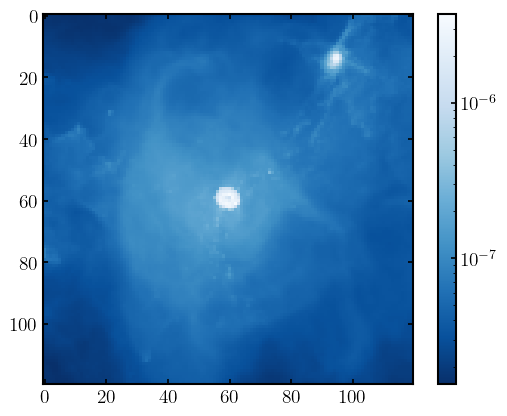

In [4]:
plt.imshow(np.sum(dens, axis=-1)/120, cmap="Blues_r", norm="log")
plt.colorbar()

In [12]:
import numpy as np
import nicegalaxy
import h5py
from numba import njit, prange
from scipy.spatial import cKDTree
import time, sys
from numba.typed import List
from tqdm import tqdm


def update_progress(fraction_done, bar_length=40):
    percent = int(fraction_done * 100)
    filled_len = int(bar_length * fraction_done)
    bar = '=' * filled_len + '-' * (bar_length - filled_len)
    sys.stdout.write(f'\r[{bar}] {percent:3d}%')
    sys.stdout.flush()


@njit
def init_mean_vels(N, velx, vely, velz, inds, previous_turbulentx, previous_turbulenty, previous_turbulentz, current_width, cell_radii):
    for i in range(N):
        bulkx = np.mean(velx[inds[i]])
        bulky = np.mean(vely[inds[i]])
        bulkz = np.mean(velz[inds[i]])
        previous_turbulentx[i] = velx[i] - bulkx
        previous_turbulenty[i] = vely[i] - bulky
        previous_turbulentz[i] = velz[i] - bulkz
        current_width[i] = max(current_width[i] + cell_radii[i], 1.05 * current_width[i])


@njit
def calculate_mean_vels(N, velx, vely, velz, inds, previous_turbulentx, previous_turbulenty, previous_turbulentz, current_width, cell_radii, shocks, coherence_length):
    for i in range(N):
        if len(inds[i]) < 2:
            continue
        bulkx = np.mean(velx[inds[i]])
        bulky = np.mean(vely[inds[i]])
        bulkz = np.mean(velz[inds[i]])

        delta = np.max(np.abs(np.array([velx[i] - bulkx, vely[i] - bulky, velz[i] - bulkz]) - 1))
        shocked = False
        for l in inds[i]:
            if shocks[l] > 1.3:
                shocked = True
                # print("im shocked")
                break
        if (delta < 0.05) or shocked:
            coherence_length[i] = current_width[i]
            current_width[i] = 0.0
        else:
            current_width[i] = max(current_width[i] + cell_radii[i], 1.05 * current_width[i])

        previous_turbulentx[i] = velx[i] - bulkx
        previous_turbulenty[i] = vely[i] - bulky
        previous_turbulentz[i] = velz[i] - bulkz


def box_smoothing_velocity_decomposition(positions, velocities, shocks):
    N = positions.shape[0]
    vols = np.zeros_like(shocks) + 91.6
    cell_radii = (3/(4*np.pi) * vols)**(1/3)
    current_width = 3 * cell_radii
    velx = velocities[:, 0]
    vely = velocities[:, 1]
    velz = velocities[:, 2]
    previous_turbulentx = np.zeros_like(velx)
    previous_turbulenty = np.zeros_like(velx)
    previous_turbulentz = np.zeros_like(velx)
    coherence_scale = np.zeros(len(positions))

    tree = cKDTree(positions)
    inds = tree.query_ball_point(positions, current_width, workers=8)
    numba_inds = List()
    for ind_list in inds:
        numba_inds.append(np.array(ind_list))

    init_mean_vels(N, velx, vely, velz, numba_inds, previous_turbulentx, previous_turbulenty, previous_turbulentz, current_width, cell_radii)

    while np.sum(current_width) > 0:
        update_progress(np.sum(current_width == 0.0)/len(positions))
        print(np.mean(current_width))
        inds = tree.query_ball_point(positions, current_width, workers=8)
        numba_inds = List()
        for ind_list in inds:
            numba_inds.append(np.array(ind_list))
        calculate_mean_vels(N, velx, vely, velz, numba_inds, previous_turbulentx, previous_turbulenty, previous_turbulentz, current_width, cell_radii, shocks, coherence_scale)
    
    previous_turbulent = np.column_stack((previous_turbulentx, previous_turbulenty, previous_turbulentz))
    return velocities - previous_turbulent, previous_turbulent, coherence_scale


In [ ]:
turb = box_smoothing_velocity_decomposition(coords, flat_vels, np.zeros(120**3))

[----------------------------------------]   0%11.185677130241906
[----------------------------------------]   0%13.982096412802509
[----------------------------------------]   0%16.77849627578454
[----------------------------------------]   0%19.574912321748727
[----------------------------------------]   0%22.371315421327107
[----------------------------------------]   0%25.16772984899302
[----------------------------------------]   0%27.964144276659134
[----------------------------------------]   0%30.760558704324872
[----------------------------------------]   0%33.55697313199073
[----------------------------------------]   0%36.35338755965684
